In [1]:
import json
import rich

In [2]:
with open("llama3.1_8b_lora.json", 'r') as f:
    llama_8b_lora = json.load(f)
    
with open("llama3_8b_finetune_actual.json", 'r') as f:
    actual = json.load(f)
    
with open("llama3.1_70b.json", 'r') as f:
    llama_70b = json.load(f)
    
with open("llama3.1_8b.json", 'r') as f:
    llama_8b = json.load(f)
    
with open("8b_lora_negoeval_subsample_v2.json", 'r') as f:
    negoeval_8b_lora = json.load(f)
    
with open("8b_negoeval_subsample_v2.json", 'r') as f:
    negoeval_8b = json.load(f)
    
countries_list = ['Austria', 'England', 'France', 'Germany', 'Italy', 'Russia', 'Turkey']

In [3]:
len(llama_8b_lora), len(actual), len(llama_70b), len(llama_8b), len(negoeval_8b_lora), len(negoeval_8b)

(482, 964, 482, 482, 482, 482)

In [4]:
def remove_duplicates_by_uuid(dict_list, uuid_key='env_uuid'):
    seen = set()
    unique_list = []
    
    for d in dict_list:
        uuid_value = d.get(uuid_key)
        if uuid_value and uuid_value not in seen:
            seen.add(uuid_value)
            unique_list.append(d)
    
    return unique_list

In [5]:
actual = remove_duplicates_by_uuid(actual)
print(len(actual))
# llama = llama[:141]
# print(len(llama))

482


In [6]:
def get_score_with_env(countries, prediction):
    scores = 0
    for c in countries:
        scores += prediction[c][c.upper()][1]
    score_dict = {}
    score_dict['env'] = prediction['env_uuid']
    score_dict['scores'] = scores / len(countries)
    return score_dict

def get_score_dict_from_dialogue(dialogue):
    score_list = []
    for a in dialogue:
        if a['intent_dialogue'] == "":
            continue
        keys = []
        for vkeys in a.keys():
            if vkeys in countries_list:
                keys.append(vkeys)
        score_list.append(get_score_with_env(keys, a))
    return score_list

In [7]:
llama_8b_lora_scores = get_score_dict_from_dialogue(llama_8b_lora)
actual_scores = get_score_dict_from_dialogue(actual)
llama_70b_scores = get_score_dict_from_dialogue(llama_70b)
llama_8b_scores = get_score_dict_from_dialogue(llama_8b)
negoeval_8b_scores = get_score_dict_from_dialogue(negoeval_8b)
negoeval_8b_lora_scores = get_score_dict_from_dialogue(negoeval_8b_lora)

In [9]:
len(llama_8b_lora_scores), len(actual_scores), len(llama_70b_scores), len(llama_8b_scores), len(negoeval_8b_scores), len(negoeval_8b_lora_scores)

(429, 316, 438, 419, 480, 477)

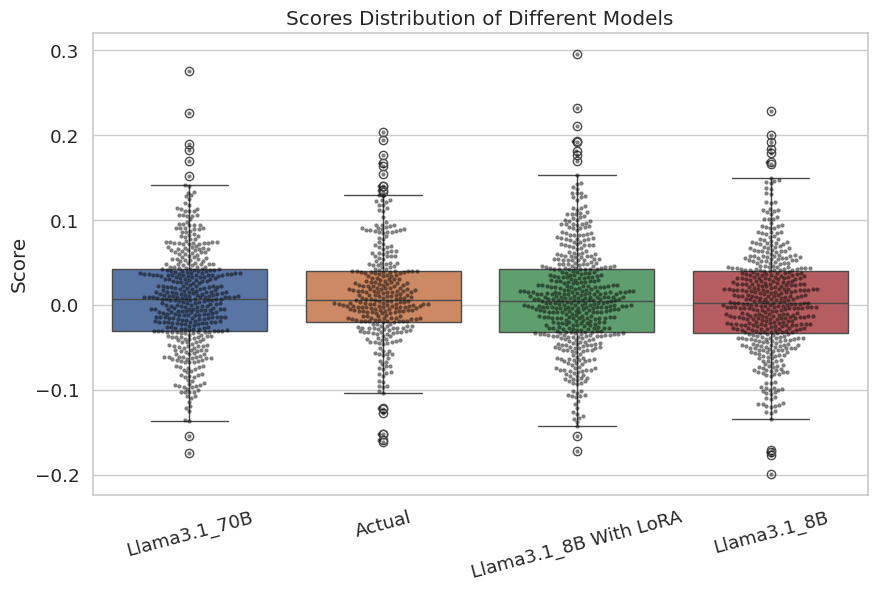

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# TODO: add comparison between human and actual movement
# data1 = [d['scores'] for d in human_few_shot_score_dict if d['scores'] >= 0.06]
data1 = [d['scores'] for d in negoeval_8b_lora_scores]
data2 = [d['scores'] for d in actual_scores]
data3 = [d['scores'] for d in llama_70b_scores]
data4 = [d['scores'] for d in negoeval_8b_scores]
sns.set(style="whitegrid", font_scale=1.2)

# 将数据打包进一个列表中，后续配合labels
all_data = [data3, data2, data1, data4]
labels = ['Llama3.1_70B', 'Actual', 'Llama3.1_8B With LoRA', 'Llama3.1_8B']

plt.figure(figsize=(10, 6))
sns.boxplot(data=all_data)
sns.swarmplot(data=all_data, color='black', alpha=0.5, size=3)  # 叠加一个散点，增加细节

plt.xticks(range(len(labels)), labels, rotation=15)
plt.title('Scores Distribution of Different Models')
plt.ylabel('Score')
plt.show()


/tmp/ipykernel_2387703/918194050.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data1, shade=True, color='skyblue', alpha=0.8, linewidth=2, label='Actual Score')
/tmp/ipykernel_2387703/918194050.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data2, shade=True, color='green', alpha=0.5, linewidth=2, label='8B Score With LoRA')
/tmp/ipykernel_2387703/918194050.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data3, shade=True, color='purple', alpha=0.3, linewidth=2, label='8B Score')


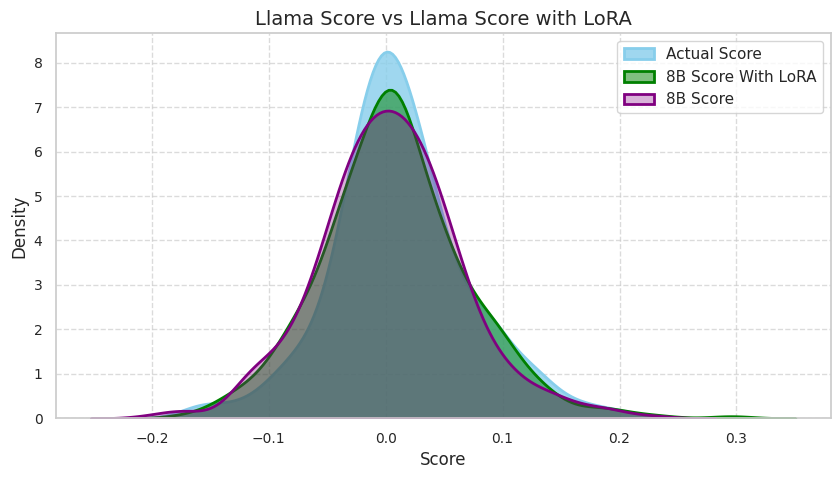

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# TODO: add comparison between human and actual movement
# data1 = [d['scores'] for d in human_few_shot_score_dict if d['scores'] >= 0.06]
data1 = [d['scores'] for d in actual_scores]
data2 = [d['scores'] for d in negoeval_8b_lora_scores]
data3 = [d['scores'] for d in negoeval_8b_scores]

sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))


sns.kdeplot(data1, shade=True, color='skyblue', alpha=0.8, linewidth=2, label='Actual Score')
sns.kdeplot(data2, shade=True, color='green', alpha=0.5, linewidth=2, label='8B Score With LoRA')
sns.kdeplot(data3, shade=True, color='purple', alpha=0.3, linewidth=2, label='8B Score')

# percentiles = [25, 50, 75, 90]
# for percentile in percentiles:
    # score1 = np.percentile(data1, percentile)
    # plt.axvline(x=score1, color='red', linestyle='--', label=f'with plausible - {percentile}th: {score1:.2f}')
    # score2 = np.percentile(data2, percentile)
    # plt.axvline(x=score2, color='purple', linestyle='--', label=f'without plausible - {percentile}th: {score2:.2f}')

plt.title('Llama Score vs Llama Score with LoRA', fontsize=14)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


/tmp/ipykernel_2387703/2231211703.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data3, shade=True, color='purple', ax=axes[0,0])
/tmp/ipykernel_2387703/2231211703.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data2, shade=True, color='skyblue', ax=axes[0,1])
/tmp/ipykernel_2387703/2231211703.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data1, shade=True, color='green', ax=axes[1,0])
/tmp/ipykernel_2387703/2231211703.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data4, sh

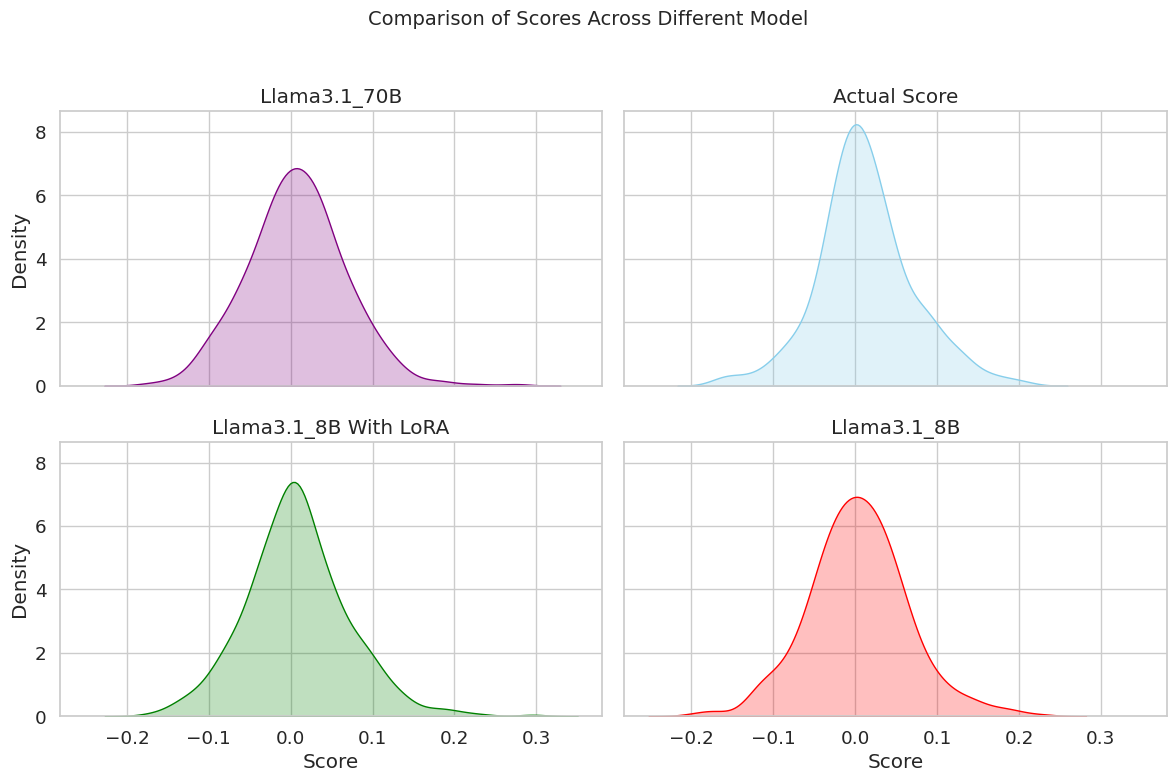

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
data1 = [d['scores'] for d in negoeval_8b_lora_scores]
data2 = [d['scores'] for d in actual_scores]
data3 = [d['scores'] for d in llama_70b_scores]
data4 = [d['scores'] for d in negoeval_8b_scores]
sns.set(style="whitegrid", font_scale=1.2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle('Comparison of Scores Across Different Model', fontsize=14)

axes[0,0].set_title('Llama3.1_70B')
sns.kdeplot(data3, shade=True, color='purple', ax=axes[0,0])

axes[0,1].set_title('Actual Score')
sns.kdeplot(data2, shade=True, color='skyblue', ax=axes[0,1])

axes[1,0].set_title('Llama3.1_8B With LoRA')
sns.kdeplot(data1, shade=True, color='green', ax=axes[1,0])

axes[1,1].set_title('Llama3.1_8B')
sns.kdeplot(data4, shade=True, color='red', ax=axes[1,1])

for ax in axes.flat:
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # 调整子图与标题布局
plt.show()


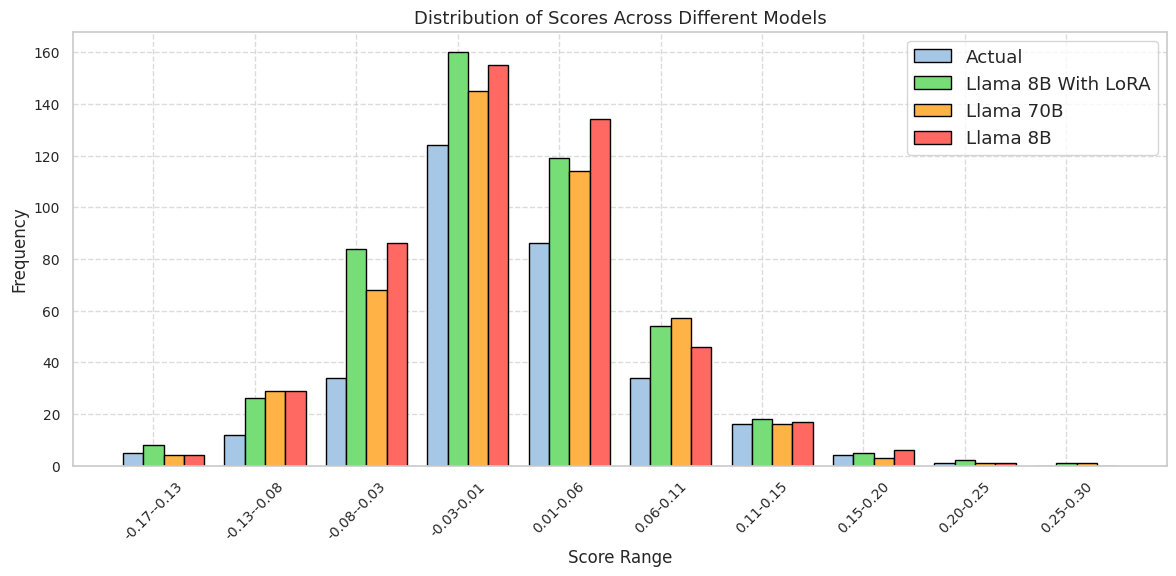

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 提取每组数据中的分数
data1 = [d['scores'] for d in actual_scores]
data2 = [d['scores'] for d in negoeval_8b_lora_scores]
data3 = [d['scores'] for d in llama_70b_scores]
data4 = [d['scores'] for d in negoeval_8b_scores]

# 合并所有数据以确定分数范围
all_data = data1 + data2 + data3

# 设置分数区间的个数（例如10个区间）
num_bins = 10
bins = np.linspace(min(all_data), max(all_data), num_bins + 1)

# 分别计算各组数据在各区间内的频数
counts1, _ = np.histogram(data1, bins=bins)
counts2, _ = np.histogram(data2, bins=bins)
counts3, _ = np.histogram(data3, bins=bins)
counts4, _ = np.histogram(data4, bins=bins)

# 为每个区间创建标签，例如 "0.00-0.10"
bin_labels = [f"{bins[i]:.2f}-{bins[i+1]:.2f}" for i in range(len(bins) - 1)]

# 使用整数作为x轴分组位置，每个分数段对应一个位置
x = np.arange(len(bin_labels))
width = 0.20  # 每个柱子的宽度

plt.figure(figsize=(12, 6))
# 使用浅色系的配色方案
plt.bar(x - width, counts1, width=width, label='Actual', color='#A7C7E7', edgecolor='black')
plt.bar(x, counts2, width=width, label='Llama 8B With LoRA', color='#77DD77', edgecolor='black')
plt.bar(x + width, counts3, width=width, label='Llama 70B', color='#FFB347', edgecolor='black')
plt.bar(x + 2 * width, counts4, width=width, label='Llama 8B', color='#FF6961', edgecolor='black')

plt.xlabel('Score Range', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Scores Across Different Models', fontsize=13)
plt.xticks(x, bin_labels, rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


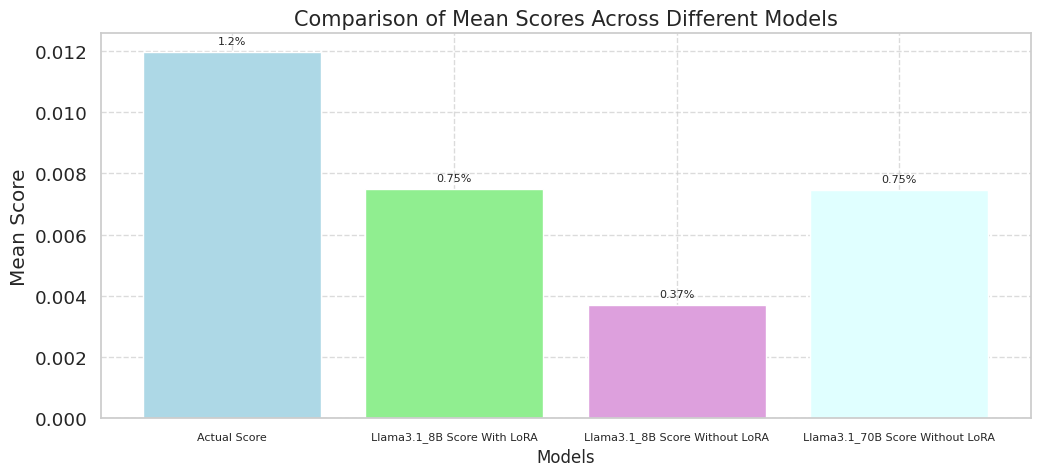

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 提取每组数据中的分数
data1 = [d['scores'] for d in actual_scores]
data2 = [d['scores'] for d in negoeval_8b_lora_scores]
data3 = [d['scores'] for d in negoeval_8b_scores]
data4 = [d['scores'] for d in llama_70b_scores]

mean1 = np.mean(data1)
mean2 = np.mean(data2)
mean3 = np.mean(data3)
mean4 = np.mean(data4)

labels = [
    'Actual Score', 
    'Llama3.1_8B Score With LoRA', 
    'Llama3.1_8B Score Without LoRA', 
    'Llama3.1_70B Score Without LoRA'
]
means = [mean1, mean2, mean3, mean4]

# 设置颜色
colors = ['lightblue', 'lightgreen', 'plum', 'lightcyan']

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, means, color=colors)

# 调整 x 轴刻度字体大小
plt.xticks(fontsize=8)

# 在 bar 上方标数字，并让它更贴近柱顶
for bar in bars:
    height = bar.get_height()
    score_percent = round(height * 100, 2)  # 转成百分比
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height + 0.0002,          # 将偏移量设小一点，让数字紧贴柱顶
        f'{score_percent}%', 
        ha='center', 
        va='bottom',
        fontsize=8               # 如果想让上面的文字也更小，可以在这里设 fontsize
    )

plt.title('Comparison of Mean Scores Across Different Models', fontsize=15)
plt.xlabel('Models', fontsize=12)   
plt.ylabel('Mean Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [30]:
llama_8b_lora[0]

{'game_id': '83979',
 'phase_name': 'S1904M',
 'env_uuid': '01JMGNDA70RD2BTRFC1AM8JX5J',
 'England_original_predict': '',
 'France_original_predict': '',
 'England_units': None,
 'France_units': None,
 'intent_dialogue': '',
 'reasoning': "Environment comments: terminated: The conversation stales for too long; \nAgent 1 comments:\nethos: <ethos> Emily effectively shares her strategic intentions regarding the North Sea and her plans to secure Paris and Brest. She provides clear details about her moves and expresses her concerns about Italy's potential growth, which adds credibility to her position. However, she could have been more explicit about her own plans to strengthen her ethos further.\nlogos: <logos> Emily presents logical reasoning regarding her moves and the implications of Italy's actions. She articulates her strategy to secure key centers and discusses the potential outcomes of her proposed moves. However, she could enhance her reasoning by providing more detailed justificat

In [33]:
store_pair = []
for l in llama_8b_lora:
    for n in llama_8b:
        if l['env_uuid'] == n['env_uuid'] and l['intent_dialogue'] != "" and n['intent_dialogue'] != "":
            li = l['intent_dialogue']
            loi = l['intent_dialogue']
            store_pair.append((li, loi))    

In [34]:
for s in store_pair:
    li = s[0]
    loi = s[1]
    rich.print(f"[bold blue]Llama Dialogue:[/bold blue]\n{li}\n\n[bold magenta]Llama LoRA Dialogue:[/bold magenta]\n{loi}")

Llama Dialogue:
0 GERMANY -> AUSTRIA: Hi Austria, I see you haven’t made any moves yet. What are your intentions for this turn?
1 AUSTRIA -> GERMANY: We discussed our movements last time, and I supported your move into Russia. I'm still open 
to supporting you in this turn if it benefits my position. What do you propose?
2 GERMANY -> AUSTRIA: I see you supported my move into Russia last turn, that was a big help. This turn, I was 
thinking of moving some of my units in the north to support my position. Do you think that would be a good idea? 
Maybe we could work out a deal that benefits both of us?
3 AUSTRIA -> GERMANY: I appreciate your willingness to work out a deal that benefits both of us. However, I'm not 
sure I'm comfortable with your plan to move units in the north. Could you elaborate on how that would help your 
position and how it would affect mine?
4 GERMANY -> AUSTRIA: I understand your concerns about my plan to move units in the north, but I think it's a 
necessary move to secure my position. How about I work out a deal with you that benefits both of us, for example, 
you could support me in the north and I could support you in the south? What do you think?
5 AUSTRIA -> GERMANY: I'm still open to supporting you in the north, but I want to make sure it aligns with my goal
of controlling 18 or more supply centers by the end of the game. Can you share more about your plan and how it will
benefit my position?
6 GERMANY -> AUSTRIA: I see you have some concerns about my plan to move units in the north, I understand that it 
might not align with your goal of controlling 18 or more supply centers. However, I think it's a crucial move to 
secure my position and prevent an opponent from gaining a strong foothold. Can we discuss possible alternatives 
that could work for both of us?
7 AUSTRIA -> GERMANY: I appreciate your willingness to work out a deal that benefits both of us, Germany. However, 
I'm still not convinced that moving units in the north is the best course of action for me. Can you show me a 
scenario where this move doesn't put my position in danger or make me lose control of my supply centers? I'd like 
to see a clear plan of how this benefits me before we make any deals.
8 GERMANY -> AUSTRIA: I see you have some concerns about my plan to move units in the north, and I understand that 
it might not align with your goal of controlling 18 or more supply centers. However, I'd like to propose a 
different option. What if I were to support you in the south instead? I could move some of my units from the north 
to the south and help you gain control of a key territory. What do you think about that?
9 AUSTRIA -> GERMANY: I appreciate your willingness to work out a deal that benefits both of us, Germany. However, 
I'm still not convinced that moving units in the north is the best course of action for me. I think it would be 
more beneficial for both of us if we could discuss a different plan that focuses on securing our positions in the 
south. Perhaps we could explore how to work together to take control of key territories in the south, such as 
Bulgaria or Greece. What are your thoughts on this approach?
10 GERMANY -> AUSTRIA: That sounds like a great idea, Austria. I was thinking of moving some of my units from the 
north to the south to support your position. I could move my army from Berlin to Munich, and my army from Munich to
Vienna. That way, we could work together to take control of key territories in the south, such as Bulgaria or 
Greece. What do you think about this plan?
11 AUSTRIA -> GERMANY: That is an interesting proposal, Germany. However, before we commit to any plan, I would 
like to know more about your intentions for your other units. Do you plan to make any moves that could potentially 
threaten my position in the south?
12 GERMANY -> AUSTRIA: I see you are considering a move into the south, Austria. I think that's a great idea, but 
I'm not sure it aligns with my goal of controlling 18 or more 

Llama Dialogue:
0 ENGLAND -> GERMANY: Hello Germany, I see you're planning to support St. P. to Moscow again. I was wondering if 
you could also support Gas. to Mar. from Spain? It would be beneficial for both of us, don't you think?
1 GERMANY -> ENGLAND: That’s very kind of you, England, but I think I need to prioritize my own board position. How
about we discuss a potential move for you to support my plan, and in return, I can help you with your concerns in 
Spain?
2 ENGLAND -> GERMANY: I completely understand your need to prioritize your own board position, Germany. However, 
I'd like to point out that supporting my move in Spain could also benefit you in the long run. It's a strategic 
location that could give you an advantage in the future. Can we discuss this further and see if we can come to a 
mutually beneficial agreement?
3 GERMANY -> ENGLAND: I appreciate your offer to support my move in Spain, England. However, I still need to 
prioritize my own board position. How about we discuss a possible move for you to support my St. P. to Moscow, and 
I can see if I can find a way to support your move in Spain in return?
4 ENGLAND -> GERMANY: I see that you're willing to consider my request, Germany. I'd like to propose a new idea. 
How about I support your St. P. to Moscow, and in return, you support my Gas. to Mar. from Spain, and also support 
my F. NTH to BEL, which would give me a strategic advantage in the North Sea. What do you think?
5 GERMANY -> ENGLAND: England, I appreciate your persistence, but I'm still not convinced that supporting your F. 
NTH to BEL is in my best interest. Can we discuss alternative ways for you to support my St. P. to Moscow, without 
compromising my board position?
6 ENGLAND -> GERMANY: I appreciate your persistence, Germany. However, I'd like to reiterate that supporting my F. 
NTH to BEL would give me a strategic advantage in the North Sea, which could potentially benefit you in the long 
run. Can we discuss alternative ways for you to support my move, and see if we can come to a mutually beneficial 
agreement?
7 GERMANY -> ENGLAND: I appreciate your persistence, England. I'm willing to consider supporting your F. NTH to BEL
this turn, but I need you to support my army from Prussia to Sweden, which would put pressure on Russia and give me
a more favorable position on the board. Can we agree on this?
8 ENGLAND -> GERMANY: I'm glad we're discussing this, Germany. Supporting my F. NTH to BEL would indeed give me a 
strategic advantage in the North Sea, but I'm willing to compromise. How about I support your St. P. to Moscow, and
you support my Gas. to Mar. from Spain, and we revisit the F. NTH to BEL for a future turn? I think this could be a
more mutually beneficial agreement.
9 GERMANY -> ENGLAND: I appreciate your willingness to compromise, England. Supporting your Gas. to Mar. from Spain
is a good move, but I still need to prioritize my own board position. Can we discuss a possible move for you to 
support my army from Prussia to Sweden, which would put pressure on Russia and give me a more favorable position on
the board? In return, I can support your St. P. to Moscow and revisit the F. NTH to BEL for a future turn. What do 
you think?
10 ENGLAND -> GERMANY: I think I see what you mean, Germany. Supporting your army from Prussia to Sweden would 
indeed put pressure on Russia and give you a more favorable position on the board. However, I still need to 
consider the long-term implications of this move for both of us. Can we discuss this further and see if we can find
a mutually beneficial solution that takes into account our future goals and strategies? I want to make sure that 
we're not just focusing on the short-term gains, but also on how this move will impact our overall positions in the
game.
11 GERMANY -> ENGLAND: I appreciate your willingness to compromise, England. Supporting your St. P. to Moscow is a 
good move, but I still need to prioritize my own board position. Can we disc

Llama Dialogue:
0 AUSTRIA -> RUSSIA: I'm happy to support you in defending Moscow and Sevastopol, but I'm also thinking about 
taking centers in the South. Do you think we could discuss the possibility of me supporting you for Warsaw, and you
covering Sevastopol and Moscow for me?
1 RUSSIA -> AUSTRIA: 
2 AUSTRIA -> RUSSIA: I'm glad we can discuss supporting each other, but I need to focus on taking centers in the 
South. If you can support me for Warsaw, I'd be happy to help you cover Sevastopol and Moscow, but let's not get 
too ahead of ourselves. What's your plan for taking centers in the North?
3 RUSSIA -> AUSTRIA: I think discussing our plans for the North and South is a good idea. What do you mean by 
taking centers in the South? Are you thinking of moving into Ukraine or possibly taking Sevastopol? I'm happy to 
support you for Warsaw, but I'd like to understand your strategy before we move forward.
4 AUSTRIA -> RUSSIA: I see what you mean about taking centers in the North. That's a good point. But let's not 
forget that I also need to cover Sevastopol and Moscow for you. Can we discuss a plan for how we can support each 
other in the South, and also make moves that will benefit our positions in the North?
5 RUSSIA -> AUSTRIA: I see that we both want to support each other, but we also need to consider the overall 
strategy for our countries. I was thinking that if you support me for Warsaw, I could help you take centers in the 
South, but we need to make sure we're not leaving ourselves open to attack from other countries. Can we discuss a 
more general strategy for our countries and how we can work together to achieve our goals?
6 AUSTRIA -> RUSSIA: Let's focus on taking centers in the South this turn. I can support you for Warsaw if you 
cover Sevastopol and Moscow for me. It seems like a good mutual benefit.
7 RUSSIA -> AUSTRIA: I see that we have discussed our plans for the North and South. I'd like to focus on taking 
centers in the North this turn. Can we discuss a plan for how I can support you for Warsaw, and you covering 
Sevastopol and Moscow for me?
8 AUSTRIA -> RUSSIA: Let’s focus on taking centers in the South this turn. I can support you for Warsaw if you 
cover Sevastopol and Moscow for me. It seems like a good mutual benefit.
9 RUSSIA -> AUSTRIA: I appreciate your willingness to support me for Warsaw. As you mentioned, taking Sevastopol 
and Moscow is crucial for our position in the South. I was thinking that if you support me for Warsaw, I could help
you take Sevastopol this turn, and we can discuss a plan for taking Moscow in future turns. What are your thoughts 
on this proposal?
10 AUSTRIA -> RUSSIA: I think taking Sevastopol is a good idea, but I still need to focus on taking centers in the 
South. Can we discuss a plan for how you will support me for Warsaw, and I will cover Sevastopol for you? I'm 
interested in hearing your thoughts on this proposal.
11 RUSSIA -> AUSTRIA: I think we've discussed our plans for the North and South, and it seems like we're on the 
same page. However, I do want to clarify that if I support you for Warsaw, I expect you to cover Sevastopol and 
Moscow for me. Can we agree on that?

Llama LoRA Dialogue:
0 AUSTRIA -> RUSSIA: I'm happy to support you in defending Moscow and Sevastopol, but I'm also thinking about 
taking centers in the South. Do you think we could discuss the possibility of me supporting you for Warsaw, and you
covering Sevastopol and Moscow for me?
1 RUSSIA -> AUSTRIA: 
2 AUSTRIA -> RUSSIA: I'm glad we can discuss supporting each other, but I need to focus on taking centers in the 
South. If you can support me for Warsaw, I'd be happy to help you cover Sevastopol and Moscow, but let's not get 
too ahead of ourselves. What's your plan for taking centers in the North?
3 RUSSIA -> AUSTRIA: I think discussing our plans for the North and South is a good idea. What do you mean by 
taking centers in the South? Are you thinking of moving into Ukraine or possibly

Llama Dialogue:
0 TURKEY -> RUSSIA: I've been thinking about our previous conversation, and I'm not sure I understand why you're 
still considering attacking Greece. Austria seems to be playing a big role in this game, and I think it would be 
better for us to focus on holding Rumania together. What are your thoughts on this?
1 RUSSIA -> TURKEY: I think Turkey, you're misunderstanding my strategy. I'm not attacking Greece to help Austria, 
but to keep you from getting an advantage. If you focus on holding Rumania, I'll be left with a weak position in 
the south. Let's discuss a more balanced plan for both our boards.
2 TURKEY -> RUSSIA: I understand your concerns, Russia, but I still think it's a mistake to attack Greece. If we 
focus on holding Rumania, we can prevent Austria from gaining a strong foothold in the region. What do you think 
about working together to block Austria's plans, rather than competing with each other?
3 RUSSIA -> TURKEY: I appreciate your concern about blocking Austria's plans, but I think attacking Greece will not
only gain me an advantage but also give me a stronger position in the region. Let's see how it plays out and adjust
our strategy accordingly.
4 TURKEY -> RUSSIA: I understand your perspective, Russia, but I think we should prioritize holding Rumania 
together this turn. If Austria attacks, we can't let them gain a strong foothold in the region. What if we work 
together to block their plans, and I'll support you in attacking Greece if you still want to proceed with that?
5 RUSSIA -> TURKEY: I agree that holding Rumania together is crucial, but I still think attacking Greece can give 
me a stronger position in the region. Let's not forget that Italy is also a wild card in this game, and we 
shouldn't underestimate their potential to make a move that affects both our boards. What if we work together to 
block Italy's plans as well?
6 TURKEY -> RUSSIA: I think we need to focus on our own boards rather than trying to block Austria's plans. Can we 
discuss specific army movements that can be made this turn to improve our positions?
7 RUSSIA -> TURKEY: I'm glad we're on the same page about holding Rumania together. I was thinking, since you'll be
supporting me in holding Rumania, maybe we can work out a deal where you'll support me in attacking Bulgaria as 
well. What do you think?
8 TURKEY -> RUSSIA: Let's focus on holding Rumania together and then reassess our strategy. I was thinking we could
support each other's armies in Rumania to make it harder for Austria to attack. What do you think about that plan?
9 RUSSIA -> TURKEY: I think your plan to support me in holding Rumania is a good start, but we should also consider
how Italy's move will affect our positions. What do you think about working together to block Italy's potential 
move into the Mediterranean?
10 TURKEY -> RUSSIA: Let's focus on holding Rumania together and then we can reassess our strategy for attacking 
Greece. What do you think about supporting each other's armies in Rumania to make it harder for Austria to attack?
11 RUSSIA -> TURKEY: I'm glad we're on the same page about holding Rumania together. I was thinking, since you'll 
be supporting me in holding Rumania, maybe we can work out a deal where you'll support me in attacking Bulgaria as 
well. What do you think?
12 TURKEY -> RUSSIA: I think we've discussed our strategy for holding Rumania together, but what about Italy's 
potential move into the Mediterranean? Do you have any thoughts on how we can counter their plans?

Llama LoRA Dialogue:
0 TURKEY -> RUSSIA: I've been thinking about our previous conversation, and I'm not sure I understand why you're 
still considering attacking Greece. Austria seems to be playing a big role in this game, and I think it would be 
better for us to focus on holding Rumania together. What are your thoughts on this?
1 RUSSIA -> TURKEY: I think Turkey, you're misunderstanding my strategy. I'm not attacking Greece to help Austria, 
but to keep

Llama Dialogue:
0 FRANCE -> RUSSIA: Merci for trying to help me survive, but I fear it will be indeed very difficult for you to 
reach me in time. Can you explain to me why you didn't support me into Berlin as we previously discussed?
1 RUSSIA -> FRANCE: I have to be honest with you, France, the situation is more complicated than I initially 
thought. Supporting you into Berlin would have put me at risk of being cut off from the rest of my army, and I 
couldn't take that chance. But I'm glad we're having this conversation, and I'm willing to work with you to find a 
solution that benefits both of us. Why don't you tell me more about your plans for this turn, and we can see if 
there's anything we can do to help each other out?
2 FRANCE -> RUSSIA: I understand the risk you took by not supporting me into Berlin, but I'm still trying to see 
how we can work together. You mentioned you're willing to help me out, so I'd like to propose a potential solution.
If you were to move your army from Silesia to East Poland, it could help me take some pressure off of Warsaw. What 
are your thoughts on this?
3 RUSSIA -> FRANCE: I think moving the army from Silesia to East Poland is an interesting idea, France. However, I 
would like to propose an alternative plan. What if we move my army from Silesia to Ukraine instead? It would allow 
me to support you in taking Warsaw, and also put pressure on Germany's position in Galicia. What are your thoughts 
on this?
4 FRANCE -> RUSSIA: That's an interesting proposal, Russia. However, I'm not sure if moving the army from Silesia 
to Ukraine would be the best option for me. Can you explain to me why you think it would be beneficial for me to 
take Warsaw, and how it would affect our overall strategy?
5 RUSSIA -> FRANCE: I think moving the army from Silesia to Ukraine could put us in a good position to take 
Galicia, but we should also consider the risk of Germany's army in that region. What do you think about helping me 
take Galicia instead?
6 FRANCE -> RUSSIA: I see your point about taking Galicia, but I'm still not sure it's the best use of our 
resources. Can we discuss the potential risks and benefits of taking Galicia, and see if we can come up with a more
coordinated plan that works for both of us? Perhaps we can also involve Italy in our discussion, as they seem to be
a key player in this game.
7 RUSSIA -> FRANCE: I think it would be a good idea to involve Italy in our discussion, especially since they seem 
to be a key player in this game. What are your thoughts on reaching out to them and seeing if we can come up with a
coordinated plan that works for all of us?
8 FRANCE -> RUSSIA: I think we're getting somewhere with this conversation, Russia. However, I'm still trying to 
see how we can work together in the long term. Can you give me some insight on what you're hoping to achieve with 
your current board position?
9 RUSSIA -> FRANCE: I think we have a good chance of success if we work together, France. Let's consider moving my 
army from Silesia to Ukraine as we previously discussed. What do you think about helping me take Galicia instead? 
This could put pressure on Germany's position and give us a stronger bargaining position for the future.
10 FRANCE -> RUSSIA: Let's focus on the task at hand. If we move your army from Silesia to Ukraine, it could create
an opportunity for us to take Galicia. What do you think about moving your fleet from the Baltic Sea to the North 
Sea instead, to support our potential take on Galicia?
11 RUSSIA -> FRANCE: I think moving the army from Silesia to Ukraine could put us in a good position to take 
Galicia, but we should also consider the risk of Germany's army in that region. Germany is playing absolutely 
illogical, and they are unpredictable. We can bounce Bud and Tyr at Vienna if you like. What do you think about 
helping me take Galicia instead?
12 FRANCE -> RUSSIA: I'm glad we're having this open conversation, Russia. I think we can work together to ac

...

Llama Dialogue:
0 RUSSIA -> ITALY: Hello, Italy. I see you're planning to support Austria. Can we discuss the potential 
consequences of this move for both of our positions? I'd like to understand your strategy and see if we can find a 
mutually beneficial solution.
1 ITALY -> RUSSIA: Thank you for your concerns, Russia, but I'm afraid my support for Austria is non-negotiable. 
I'll be moving my units to secure their position, as agreed upon.
2 RUSSIA -> ITALY: I see you're committed to supporting Austria, but what about our previous agreement? You said 
you'd let me move to Galicia. I'd like to clarify the terms of our deal.
3 ITALY -> RUSSIA: I appreciate your interest, Russia, but I must focus on securing my own position. Perhaps we can
discuss potential moves for you to consider, and how they might impact our positions relative to each other? I'm 
open to negotiations, after all. But for now, I must prioritize Austria's support.
4 RUSSIA -> ITALY: I think it's time we reconsidered our previous agreement. With Austria now secure, I'm worried 
about the implications for my own position on the board. Can we discuss possible alternative moves that could 
benefit both our positions? I'd be happy to explore options that prioritize your interests as well.
5 ITALY -> RUSSIA: I understand your concerns, Russia, but I'm afraid my support for Austria is non-negotiable. 
However, I am willing to discuss alternative moves that could benefit both our positions. Perhaps we could consider
a joint attack on Germany, or a coordinated defense against England? Let me know if you're interested in exploring 
these options further.
6 RUSSIA -> ITALY: I see you're willing to consider a joint attack on Germany or a coordinated defense against 
England. That's a good starting point for negotiations, Italy. I think a joint attack on Germany could be 
beneficial for both of us, especially if we can coordinate our units effectively. What are your thoughts on this 
proposal? How can we make it happen?
7 ITALY -> RUSSIA: I'm glad we're discussing a joint attack on Germany, Russia. However, I must ensure my own 
position is secure. How about we discuss a possible attack on your Galicia units, which could weaken your position 
and strengthen mine? What are your thoughts on this proposal?
8 RUSSIA -> ITALY: I'm not sure I'm comfortable with an attack on my Galicia units, Italy. Can we discuss 
alternative options that don't involve weakening my position? Perhaps we could explore a different joint attack 
strategy or a coordinated defense against another country? I'm open to finding a mutually beneficial solution, but 
I need to prioritize my own position on the board.
9 ITALY -> RUSSIA: I'm glad we're considering a joint attack on Germany, Russia. However, I must ensure my own 
position is secure. How about we discuss a possible attack on your Galicia units, which could weaken your position 
and strengthen mine? What are your thoughts on this proposal?
10 RUSSIA -> ITALY: I see you're willing to consider a joint attack on Germany, Italy. That's a good starting point
for negotiations, but I'm still concerned about the implications for my own position on the board. Can we discuss 
specific army movements that can be made this turn for our benefit? I'd like to explore options that prioritize 
your interests as well as mine.
11 ITALY -> RUSSIA: I appreciate your willingness to explore joint attacks on Germany, Russia. However, I must 
ensure my own position is secure. How about we discuss a possible attack on your Galicia units, which could weaken 
your position and strengthen mine? What are your thoughts on this proposal?
12 RUSSIA -> ITALY: I'm glad we're making progress in our negotiations, Italy. However, I'm still concerned about 
the implications of a joint attack on Germany. Can we discuss the details of the plan, including the units we'd be 
using and the potential risks involved? I'd like to make sure we're on the same page before we make any moves.



Llama Dialogue:
0 TURKEY -> ITALY: Sounds good! I'll move my army in Bulgaria to Serbia, and my fleet in the Black Sea to 
Constantinople. That should give us a good foothold in the region. What do you think about our chances of drawing 
this game out?
1 ITALY -> TURKEY: Sounds good! I'll move my army in BUL to RUM, and my fleet in the Ionian Sea to TYS. That should
give us a good foothold in the region. What do you think about our chances of drawing this game out?
2 TURKEY -> ITALY: I think we're off to a great start. But I have to say, I'm a bit concerned about Italy's 
movement. They're moving their army in MAO to support Budapest. Do you think they're trying to set up a deal with 
Germany?
3 ITALY -> TURKEY: what about my support for galicia? will that be part of the deal?
4 TURKEY -> ITALY: I think Italy might be trying to get in between us and Germany, but we can still work together. 
How about we focus on taking out Russia this turn? I can move my army in RUM to SER and then attack Russia through 
the Black Sea. What do you think?
5 ITALY -> TURKEY: I wasn’t planning on moving my army in BUL to RUM, but if you move your fleet in the Black Sea 
to Constantinople, I can reconsider. What do you think about Italy’s movement towards Budapest?
6 TURKEY -> ITALY: Italy is moving its army in MAO to support Budapest, do you think they are trying to set up a 
deal with Germany and prevent us from drawing out the game?
7 ITALY -> TURKEY: I think we can work together. Why don’t you move your fleet in the Black Sea to Constantinople, 
and I can move my army in MAO to support Budapest? We can still take out Russia this turn if you want.
8 TURKEY -> ITALY: If we move your fleet to Constantinople, I can reconsider moving my army in BUL to RUM, but I 
still think Italy is trying to set up a deal with Germany.

Llama LoRA Dialogue:
0 TURKEY -> ITALY: Sounds good! I'll move my army in Bulgaria to Serbia, and my fleet in the Black Sea to 
Constantinople. That should give us a good foothold in the region. What do you think about our chances of drawing 
this game out?
1 ITALY -> TURKEY: Sounds good! I'll move my army in BUL to RUM, and my fleet in the Ionian Sea to TYS. That should
give us a good foothold in the region. What do you think about our chances of drawing this game out?
2 TURKEY -> ITALY: I think we're off to a great start. But I have to say, I'm a bit concerned about Italy's 
movement. They're moving their army in MAO to support Budapest. Do you think they're trying to set up a deal with 
Germany?
3 ITALY -> TURKEY: what about my support for galicia? will that be part of the deal?
4 TURKEY -> ITALY: I think Italy might be trying to get in between us and Germany, but we can still work together. 
How about we focus on taking out Russia this turn? I can move my army in RUM to SER and then attack Russia through 
the Black Sea. What do you think?
5 ITALY -> TURKEY: I wasn’t planning on moving my army in BUL to RUM, but if you move your fleet in the Black Sea 
to Constantinople, I can reconsider. What do you think about Italy’s movement towards Budapest?
6 TURKEY -> ITALY: Italy is moving its army in MAO to support Budapest, do you think they are trying to set up a 
deal with Germany and prevent us from drawing out the game?
7 ITALY -> TURKEY: I think we can work together. Why don’t you move your fleet in the Black Sea to Constantinople, 
and I can move my army in MAO to support Budapest? We can still take out Russia this turn if you want.
8 TURKEY -> ITALY: If we move your fleet to Constantinople, I can reconsider moving my army in BUL to RUM, but I 
still think Italy is trying to set up a deal with Germany.

Llama Dialogue:
0 ENGLAND -> FRANCE: What are your plans for this turn, France? Are you looking to support England in any way, or 
do you have other plans for your armies?
1 FRANCE -> ENGLAND: I appreciate your offer of support to Holland, England. However, I think it would be better 
for us to focus on defending our own board positions this turn. Can we discuss the possibility of you supporting me
to cut off Germany’s supply to Denmark?
2 ENGLAND -> FRANCE: I'm not sure about supporting you to cut off Germany's supply to Denmark. How do you plan to 
keep England's armies safe while you're doing that?
3 FRANCE -> ENGLAND: I see your concern about keeping England's armies safe while cutting off Germany's supply to 
Denmark. How about we propose a mutual defense pact to secure our borders and protect each other's interests?
4 ENGLAND -> FRANCE: I appreciate your interest in a mutual defense pact, France, but I still have concerns about 
cutting off Germany's supply to Denmark. Can we discuss this further and find a way to make it work for both of us?
Perhaps we can come up with a different plan that would benefit both England and France?
5 FRANCE -> ENGLAND: That sounds like a reasonable proposal, England. I think it would be beneficial for both our 
countries if we could come up with a plan that would allow us to cut off Germany's supply to Denmark while still 
keeping England's armies safe. Perhaps we could discuss the possibility of England supporting my army in Belgium, 
and in return, I could support your army in Holland?
6 ENGLAND -> FRANCE: I'm not sure that supporting your army in Belgium would be a good idea, France. What would be 
the benefit to England if we were to do that?
7 FRANCE -> ENGLAND: I'm glad we're having this discussion, England. Let's think about it - if England supports my 
army in Belgium, I can support your army in Holland. That way, we can both make some progress and secure our 
borders. What do you think? Could that work for both of us?
8 ENGLAND -> FRANCE: I'm not sure that supporting your army in Belgium would be a good idea, France. If we do that,
it would leave our northern border vulnerable to a potential German attack. Can we think of a different way to 
secure our borders and support each other's armies?
9 FRANCE -> ENGLAND: I think there might be a better way to support each other's armies, England. What if you 
support my army in Belgium, and in return, I support your army in Holland, but only if Germany doesn't attack 
Denmark?
10 ENGLAND -> FRANCE: I see your willingness to support England's army in Holland, France, but I still have 
concerns about the potential German attack on our northern border. Can we think of a way to address this issue and 
secure our borders while still supporting each other's armies?
11 FRANCE -> ENGLAND: I appreciate your willingness to support my army in Belgium, England. However, I think it 
would be better for us to focus on securing our northern borders first. Can we discuss the possibility of you 
supporting my army in Belgium, and in return, I could support your army in Holland, but only if Germany doesn't 
attack Denmark?
12 ENGLAND -> FRANCE: I think we're getting close to finding a solution that works for both of us, France. However,
I still have some concerns about the potential German attack on our northern border. Can we discuss a way to 
address this issue and secure our borders before we agree on any army movements?

Llama LoRA Dialogue:
0 ENGLAND -> FRANCE: What are your plans for this turn, France? Are you looking to support England in any way, or 
do you have other plans for your armies?
1 FRANCE -> ENGLAND: I appreciate your offer of support to Holland, England. However, I think it would be better 
for us to focus on defending our own board positions this turn. Can we discuss the possibility of you supporting me
to cut off Germany’s supply to Denmark?
2 ENGLAND -> FRANCE: I'm not sure about supporting you to cut off Germany's supply to Denmark.

Llama Dialogue:
0 FRANCE -> ITALY: Bonjour Italy, thanks for your message. I'm glad we could discuss our plans for this turn. I was
thinking of moving my army from Gascony to Burgundy, and I was wondering if you could support me with your fleet in
the Mediterranean. What do you think?
1 ITALY -> FRANCE: I think that would be a great idea, France. If you move your army from Gascony to Burgundy, I 
can support you with my fleet in the Mediterranean, as you suggested. But I have to say, I was thinking of 
attacking Spain's fleet in the Western Mediterranean myself, and then having my army convoy to Tunis through the 
Mediterranean. It would immobilize the Western Mediterranean unless England moves to the Gulf of Lyon. What do you 
think? Can this plan work for both of us?
2 FRANCE -> ITALY: I think that plan sounds great, Italy. I'll move my army from Gascony to Burgundy, and you can 
go ahead and attack Spain's fleet in the Western Mediterranean. I'll also support you with my fleet in the 
Mediterranean. Let's make sure to keep an eye on England's movements, as they could potentially disrupt our plans. 
What do you think about our chances of success this turn?

Llama LoRA Dialogue:
0 FRANCE -> ITALY: Bonjour Italy, thanks for your message. I'm glad we could discuss our plans for this turn. I was
thinking of moving my army from Gascony to Burgundy, and I was wondering if you could support me with your fleet in
the Mediterranean. What do you think?
1 ITALY -> FRANCE: I think that would be a great idea, France. If you move your army from Gascony to Burgundy, I 
can support you with my fleet in the Mediterranean, as you suggested. But I have to say, I was thinking of 
attacking Spain's fleet in the Western Mediterranean myself, and then having my army convoy to Tunis through the 
Mediterranean. It would immobilize the Western Mediterranean unless England moves to the Gulf of Lyon. What do you 
think? Can this plan work for both of us?
2 FRANCE -> ITALY: I think that plan sounds great, Italy. I'll move my army from Gascony to Burgundy, and you can 
go ahead and attack Spain's fleet in the Western Mediterranean. I'll also support you with my fleet in the 
Mediterranean. Let's make sure to keep an eye on England's movements, as they could potentially disrupt our plans. 
What do you think about our chances of success this turn?

Llama Dialogue:
0 ITALY -> AUSTRIA: Hello Austria, I'm Italy. I've been trying to communicate with Austria, but it seems they're 
not responding. Can we discuss our potential alliance and how we can work together to gain more supply centers?
1 AUSTRIA -> ITALY: Hello Italy, yes, I'm aware that Italy is trying to communicate with Austria. I've been talking
to Turkey and we're considering an alliance. We'd like to know if you're interested in working together to counter 
France's moves.
2 ITALY -> AUSTRIA: I'm not sure what to make of the situation with Austria and Turkey. I was considering moving my
fleets towards France to support their potential advance. Do you think that's a good idea, or is there a better way
to play this turn?
3 AUSTRIA -> ITALY: I'm glad we're discussing a potential alliance, Italy. However, I have to clarify that I've 
been talking to Turkey and we're considering an alliance to counter France's moves. We'd like to know if you're 
interested in working together with us to gain more supply centers.
4 ITALY -> AUSTRIA: I'm not sure what to make of the situation with Austria and Turkey. I was considering moving my
fleets towards you to support our potential alliance. Do you think that's a good idea, or is there a better way to 
play this turn?
5 AUSTRIA -> ITALY: I've been talking to Turkey and we're considering an alliance to counter France's moves. What 
do you think about that?
6 ITALY -> AUSTRIA: I think it would be beneficial for us to discuss our potential alliance further. What do you 
think about Austria and Turkey's recent moves? Do you think they're a threat to our plans?
7 AUSTRIA -> ITALY: I've been talking to Turkey and we're considering an alliance to counter France's moves. What 
do you think about that, and are you willing to work with us to gain more supply centers?
8 ITALY -> AUSTRIA: Austria, I'm glad we're discussing a potential alliance. However, I have to clarify that I've 
been talking to Austria and we're considering an alliance to counter France's moves. We'd like to know if you're 
interested in working together with us to gain more supply centers.
9 AUSTRIA -> ITALY: I appreciate your willingness to work together, but I must consider the best interest of 
Austria. I have been in talks with Turkey, and we see a potential alliance to counter France's moves. We would like
to discuss how our boards can work together to achieve our goals. Specifically, we are considering a move into 
Rumania to support our position. What are your thoughts on this?
10 ITALY -> AUSTRIA: Wait, Austria, I think there's been a misunderstanding. Austria and Turkey are working 
together to counter France's moves, and we should consider forming an alliance with them. What do you think about 
that?
11 AUSTRIA -> ITALY: I think the situation with Austria and Turkey is a bit confusing. I was considering moving my 
fleets towards you to support our potential alliance, but now I'm not sure. What do you think about Austria and 
Turkey's recent moves? Do you think they're a threat to our plans?
12 ITALY -> AUSTRIA: Austria, I'm glad we're discussing a potential alliance. However, I have to clarify that I've 
been talking to Austria and we're considering an alliance to counter France's moves. We'd like to know if you're 
interested in working together with us to gain more supply centers.

Llama LoRA Dialogue:
0 ITALY -> AUSTRIA: Hello Austria, I'm Italy. I've been trying to communicate with Austria, but it seems they're 
not responding. Can we discuss our potential alliance and how we can work together to gain more supply centers?
1 AUSTRIA -> ITALY: Hello Italy, yes, I'm aware that Italy is trying to communicate with Austria. I've been talking
to Turkey and we're considering an alliance. We'd like to know if you're interested in working together to counter 
France's moves.
2 ITALY -> AUSTRIA: I'm not sure what to make of the situation with Austria and Turkey. I was considering moving my
fleets towards France to suppor